Prediksi Iris virginica (5.5, 1.7): [1.]


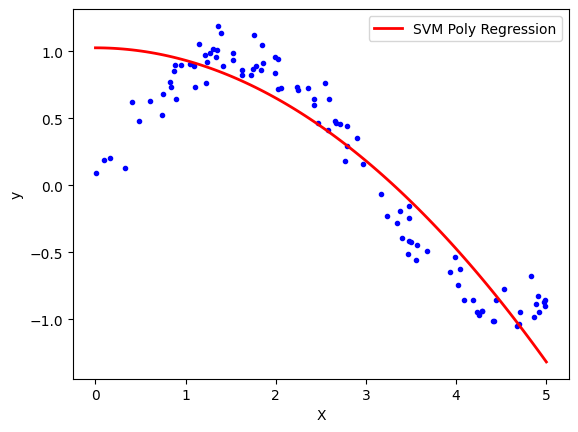

In [44]:
# 📌 Install dependensi (opsional, biasanya sudah tersedia di Colab)
# !pip install scikit-learn matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.svm import LinearSVC, SVC, LinearSVR, SVR
from sklearn.datasets import make_moons

##############################################
# 1️⃣ Linear SVM Classification
##############################################

iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = (iris["target"] == 2).astype(np.float64)  # 1 jika Iris virginica, 0 selain itu

svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(C=1, loss="hinge"))
])

svm_clf.fit(X, y)
print("Prediksi Iris virginica (5.5, 1.7):", svm_clf.predict([[5.5, 1.7]]))

##############################################
# 2️⃣ Nonlinear SVM Classification (Polynomial Features)
##############################################

X_moons, y_moons = make_moons(n_samples=100, noise=0.15, random_state=42)

polynomial_svm_clf = Pipeline([
    ("poly_features", PolynomialFeatures(degree=3)),
    ("scaler", StandardScaler()),
    ("svm_clf", LinearSVC(C=10, loss="hinge", max_iter=5000))
])

polynomial_svm_clf.fit(X_moons, y_moons)

##############################################
# 3️⃣ Nonlinear SVM Classification (Polynomial Kernel)
##############################################

poly_kernel_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel="poly", degree=3, coef0=1, C=5))
])

poly_kernel_svm_clf.fit(X_moons, y_moons)

##############################################
# 4️⃣ Nonlinear SVM Classification (Gaussian RBF Kernel)
##############################################

rbf_kernel_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel="rbf", gamma=5, C=0.001))
])

rbf_kernel_svm_clf.fit(X_moons, y_moons)

##############################################
# 5️⃣ SVM Regression (Linear)
##############################################

# Data acak untuk regresi linear
np.random.seed(42)
X_reg = 2 * np.random.rand(50, 1)
y_reg = 4 + 3 * X_reg + np.random.randn(50, 1)

svm_reg = LinearSVR(epsilon=1.5)
svm_reg.fit(X_reg, y_reg.ravel())

##############################################
# 6️⃣ SVM Regression (Polynomial Kernel)
##############################################

# Data acak untuk regresi non-linear
X_reg2 = np.sort(np.random.rand(100, 1) * 5, axis=0)
y_reg2 = np.sin(X_reg2).ravel() + np.random.randn(100) * 0.1

svm_poly_reg = SVR(kernel="poly", degree=2, C=100, epsilon=0.1)
svm_poly_reg.fit(X_reg2, y_reg2)

##############################################
# ✅ Visualisasi Contoh (Opsional)
##############################################

# Visualisasi hasil SVM Polynomial Regression
X_plot = np.linspace(0, 5, 100).reshape(-1, 1)
y_pred = svm_poly_reg.predict(X_plot)

plt.plot(X_reg2, y_reg2, "b.")
plt.plot(X_plot, y_pred, "r-", linewidth=2, label="SVM Poly Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# 📚 Chapter 4 - Training Models

---

## 🔸 1. Linear Regression
Model **Linear Regression** digunakan untuk memprediksi nilai kontinu berdasarkan kombinasi linier dari fitur input.

**Persamaan Linear Regression:**

\[
\hat{y} = \theta_0 + \theta_1x_1 + \cdots + \theta_nx_n
\]
Atau ditulis dalam bentuk vektor:

\[
\hat{y} = \theta^T x
\]

**Tujuan:** mencari parameter **θ** yang meminimalkan **Mean Squared Error (MSE)**.

---

## 🔧 Training Linear Regression
### ✅ **Normal Equation**
Metode langsung (closed-form) untuk mencari parameter optimal:

\[
\theta = (X^T X)^{-1} X^T y
\]

Cocok untuk dataset kecil hingga menengah.

### ✅ **Gradient Descent (GD)**
Algoritma iteratif untuk meminimalkan fungsi biaya:

\[
\theta = \theta - \eta \cdot \nabla_\theta MSE(\theta)
\]

- **η (eta)** = learning rate
- Ada **3 jenis Gradient Descent**:
  - **Batch GD** → seluruh dataset digunakan untuk menghitung gradien
  - **Stochastic GD (SGD)** → 1 instance digunakan tiap iterasi → lebih cepat tapi lebih bervariasi
  - **Mini-batch GD** → sebagian kecil dataset digunakan → kompromi antara Batch dan SGD

### ⚠️ **Feature Scaling**
Agar GD cepat konvergen → gunakan **StandardScaler** untuk scaling fitur.

---

## 🔸 2. Polynomial Regression
Menambahkan fitur polinomial (misalnya, \(x^2, x^3, \dots\)) agar Linear Regression dapat memodelkan hubungan non-linear.

**Risiko:** mudah overfitting → perlu evaluasi model dan regularisasi.

---

## 🔸 3. Learning Curves
Grafik **RMSE** terhadap ukuran dataset training.

- **Underfitting (bias tinggi):** Train error & Validation error sama-sama tinggi
- **Overfitting (variance tinggi):** Train error rendah, Validation error tinggi

---

## 🔸 4. Regularization
Regularisasi = menambahkan penalti terhadap besar koefisien parameter model untuk mencegah overfitting.

### 🔧 Jenis-jenis Regularisasi:
- **Ridge Regression (L2):**

\[
J(\theta) = MSE(\theta) + \alpha \sum_{i=1}^{n} \theta_i^2
\]

- **Lasso Regression (L1):**

\[
J(\theta) = MSE(\theta) + \alpha \sum_{i=1}^{n} |\theta_i|
\]

- **Elastic Net:** Gabungan L1 dan L2.

---

## 🔸 5. Early Stopping
Menghentikan training lebih awal saat error pada validation set mulai meningkat → mencegah overfitting.

---

## 🔸 6. Logistic Regression (Binary Classification)
Model klasifikasi biner → memprediksi probabilitas menggunakan fungsi sigmoid:

\[
p = \frac{1}{1 + e^{-(\theta^T x)}}
\]

**Loss Function (Log Loss):**

\[
J(\theta) = -\frac{1}{m} \sum_{i=1}^m \left[ y_i \log(p_i) + (1-y_i)\log(1-p_i) \right]
\]

---

## 🔸 7. Softmax Regression (Multiclass Classification)
Generalized Logistic Regression untuk multiclass classification.

\[
p_k = \frac{e^{s_k(x)}}{\sum_{j=1}^K e^{s_j(x)}}
\]
- \(s_k(x) = \theta_k^T x\)

**Loss Function:** Cross-Entropy Loss

---

## ⚖️ Bias-Variance Trade-off
| **Bias Tinggi (Underfitting)** | **Variance Tinggi (Overfitting)** |
|-------------------------------|----------------------------------|
| Model terlalu sederhana       | Model terlalu kompleks          |

Tujuan → Cari **keseimbangan** antara bias dan variance agar performa optimal.

---

## ✅ Kesimpulan
- Linear Regression → untuk regresi linear
- Polynomial Regression → untuk data non-linear
- Regularisasi → mencegah overfitting
- Logistic Regression → klasifikasi biner
- Softmax Regression → klasifikasi multi-kelas
- Feature Scaling & Early Stopping → meningkatkan kinerja training